In [ ]:
# Cell 1: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT/'figures'/'figures_Hurdle'/'figures_Hurdle_AR1_GRW_S'
RESULTS = PROJ_ROOT/'results'/'results_Hurdle'/'results_Hurdle_AR1_GRW_S'
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)


In [20]:
# Cell 2: analysis settings

EPS = 0.49
N = 50000
Y = 20
SEED = 63

rng = np.random.default_rng(SEED)


In [21]:
# Cell 3: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

print(df_original.shape)
df_original.head()


(54948, 21)


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,phd_rank,phd_year,place,pubs,pubs_adj,pubs_with_corr,pubs_with_corr_adj,recordDate,year,CareerAge
0,0.342857,0.342857,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,2,3.902057,2,3.902057,6/6/11,1998,-3
1,0.250000,0.250000,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,1,1.875160,1,1.875160,6/6/11,1999,-2
2,1.833333,1.833333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,7.214900,4,7.214900,6/6/11,2000,-1
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,3,5.209137,3,5.209137,6/6/11,2001,0
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,6.691238,4,6.691238,6/6/11,2002,1


In [22]:
# Cell 4: build empirical panel

df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)
working_df["is_active"] = (working_df["pubs_adj"] > 0).astype(int)

working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)
working_df["is_active_next"] = working_df.groupby("dblp_id")["is_active"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["pubs_adj", "pubs_adj_next", "is_active", "is_active_next"]).copy())

print("Rows in orig:", len(working_df))
print("Rows w/ ok 1yr trans:", len(working_df_fit))
print()
print(working_df_fit[["pubs_adj", "pubs_adj_next", "log_pubs_adj", "log_pubs_next", "log_delta"]].describe())


Rows in orig: 54948
Rows w/ ok 1yr trans: 34701

           pubs_adj  pubs_adj_next  log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000   34701.000000  34701.000000
mean       6.426378       6.446431      1.442084       1.448262      0.006178
std        6.475154       6.499782      1.131298       1.123265      1.057639
min        0.000000       0.000000     -0.713350      -0.713350     -5.028100
25%        2.031715       2.031715      0.924939       0.924939     -0.509761
50%        4.775004       4.775004      1.661082       1.661082     -0.026502
75%        9.012406       9.012406      2.251545       2.251545      0.523108
max       80.686837      80.686837      4.396630       4.396630      4.138016


In [23]:
# Cell 5: career stages

stage_order = ["0-4", "5-7", "8-13", "14-20"]

def assign_career_stage(year):
    if 0 <= year <= 4:
        return "0-4"
    elif 5 <= year <= 7:
        return "5-7"
    elif 8 <= year <= 13:
        return "8-13"
    elif 14 <= year <= 20:
        return "14-20"
    else:
        return np.nan

working_df["career_stage"] = working_df["CareerAge"].apply(assign_career_stage)
working_df_fit["career_stage"] = working_df_fit["CareerAge"].apply(assign_career_stage)

print("Prod obs by stage:")
print(working_df["career_stage"].value_counts().reindex(stage_order))
print()
print("Trans obs by starting-year stage:")
print(working_df_fit["career_stage"].value_counts().reindex(stage_order))


Prod obs by stage:
career_stage
0-4      10961
5-7       6647
8-13     11114
14-20     8404
Name: count, dtype: int64

Trans obs by starting-year stage:
career_stage
0-4      10918
5-7       6401
8-13     10496
14-20     6886
Name: count, dtype: int64


In [24]:
# Cell 6: build binary states and transition data

id_col = "dblp_id"
age_col = "CareerAge"
prod_col = "pubs_adj"

state_labels = {
    0: "No pubs",
    1: "Some pubs",}

state_order = [0, 1]
n_states = len(state_order)

df = working_df[working_df[age_col].between(0, Y)].copy()
df["state"] = (df[prod_col] > 0).astype(int)

trans = working_df_fit.copy()
trans["state"] = trans["is_active"].astype(int)
trans["next_state"] = trans["is_active_next"].astype(int)

print(df[[id_col, age_col, prod_col, "state"]].head())
print()
print("State counts:")
print(df["state"].map(state_labels).value_counts())
print()
print("Transition counts by type:")
print(pd.crosstab(trans["state"], trans["next_state"]).rename(index=state_labels, columns=state_labels))


                        dblp_id  CareerAge   pubs_adj  state
3  =Ccedil=etintemel:Ugur2001.0          0   5.209137      1
4  =Ccedil=etintemel:Ugur2001.0          1   6.691238      1
5  =Ccedil=etintemel:Ugur2001.0          2  12.901876      1
6  =Ccedil=etintemel:Ugur2001.0          3   4.667694      1
7  =Ccedil=etintemel:Ugur2001.0          4  12.016541      1

State counts:
state
Some pubs    31549
No pubs       5577
Name: count, dtype: int64

Transition counts by type:
next_state  No pubs  Some pubs
state                         
No pubs        2318       3061
Some pubs      2823      26499


In [25]:
# Cell 7: yearwise binary transition matrices

def transition_counts_and_probs(g):
    counts = pd.crosstab(g["state"], g["next_state"])
    counts = counts.reindex(index=state_order, columns=state_order, fill_value=0)
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return counts, probs

global_counts, global_P = transition_counts_and_probs(trans)

year_counts = {}
year_P = {}

year_transition_rows = []

for year in range(Y):
    g = trans[trans[age_col] == year]
    counts, probs = transition_counts_and_probs(g)

    # Fallback only matters if a row is undefined for some sparse year.
    probs = probs.combine_first(global_P)

    year_counts[year] = counts
    year_P[year] = probs

    year_transition_rows.append({
        "year": year,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

year_transition_summary = pd.DataFrame(year_transition_rows)

print("Global transition probabilities:")
print(global_P.rename(index=state_labels, columns=state_labels).round(3))
print()
print("Yearwise transition summary:")
display(year_transition_summary.round(3))


Global transition probabilities:
next_state  No pubs  Some pubs
state                         
No pubs       0.431      0.569
Some pubs     0.096      0.904

Yearwise transition summary:


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


In [26]:
# Cell 8: stagewise binary transition summary, for comparison

stage_counts = {}
stage_P = {}
stage_transition_rows = []

for stage in stage_order:
    g = trans[trans["career_stage"] == stage]
    counts, probs = transition_counts_and_probs(g)
    probs = probs.combine_first(global_P)

    stage_counts[stage] = counts
    stage_P[stage] = probs

    stage_transition_rows.append({
        "stage": stage,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

stage_transition_summary = pd.DataFrame(stage_transition_rows)

display(stage_transition_summary.round(3))


,stage,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0-4,10918,0.365,0.635,0.099,0.901
1,5-7,6401,0.419,0.581,0.083,0.917
2,8-13,10496,0.463,0.537,0.094,0.906
3,14-20,6886,0.485,0.515,0.109,0.891


In [27]:
# Cell 9: fit positive-only stagewise log AR(1) models

positive_ar1_fit = working_df_fit[(working_df_fit["pubs_adj"] > 0) & (working_df_fit["pubs_adj_next"] > 0)].copy()
positive_ar1_fit["log_pubs_pos"] = np.log(positive_ar1_fit["pubs_adj"])
positive_ar1_fit["log_pubs_pos_next"] = np.log(positive_ar1_fit["pubs_adj_next"])

def fit_positive_log_ar1(subset):
    x = subset["log_pubs_pos"].to_numpy()
    y = subset["log_pubs_pos_next"].to_numpy()

    if len(x) < 3:
        return {
            "n": len(x),
            "intercept": np.nan,
            "beta": np.nan,
            "sigma_resid": np.nan,
            "var_resid": np.nan,
            "implied_stationary_mean_log": np.nan,
            "implied_stationary_var_log": np.nan,
            "mean_resid": np.nan,
            "sd_resid": np.nan,}

    X = np.column_stack([np.ones(len(x)), x])

    intercept, beta = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = intercept + beta * x
    resid = y - y_hat

    sigma = np.sqrt(np.mean(resid**2))
    var = sigma**2

    if abs(beta) < 1:
        implied_mean = intercept / (1 - beta)
        implied_var = var / (1 - beta**2)
    else:
        implied_mean = np.nan
        implied_var = np.nan

    return {
        "n": len(x),
        "intercept": intercept,
        "beta": beta,
        "sigma_resid": sigma,
        "var_resid": var,
        "implied_stationary_mean_log": implied_mean,
        "implied_stationary_var_log": implied_var,
        "mean_resid": resid.mean(),
        "sd_resid": resid.std(ddof=0),}


global_ar1_params = pd.DataFrame([{"model": "global_positive", **fit_positive_log_ar1(positive_ar1_fit)}])

stage_ar1_rows = []

for stage in stage_order:
    subset = positive_ar1_fit[positive_ar1_fit["career_stage"] == stage].copy()
    stage_ar1_rows.append({"stage": stage, **fit_positive_log_ar1(subset)})

stage_ar1_params = pd.DataFrame(stage_ar1_rows)

print("Global positive-only AR(1)")
display(global_ar1_params)

print("Stagewise positive-only AR(1)")
display(stage_ar1_params)

print("problematic abs beta >= 1")
display(stage_ar1_params.loc[stage_ar1_params["beta"].abs() >= 1])


Global positive-only AR(1)


,model,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,global_positive,26499,0.706327,0.597931,0.646869,0.41844,1.75673,0.65129,-2.150478e-16,0.646869


Stagewise positive-only AR(1)


,stage,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0-4,8298,0.872684,0.549230,0.635833,0.404284,1.935984,0.578916,1.488860e-15,0.635833
1,5-7,5159,0.706953,0.591138,0.638334,0.407471,1.729075,0.626343,-7.051713e-16,0.638334
2,8-13,8084,0.617526,0.621251,0.651541,0.424506,1.630435,0.691324,7.669933e-16,0.651541
3,14-20,4958,0.558044,0.654173,0.648712,0.420827,1.613650,0.735637,7.588390e-16,0.648712


problematic abs beta >= 1


,stage,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid


In [28]:
# Cell 10: fit initial and restart exponential models

q0_empirical = working_df.loc[working_df["CareerAge"] == 0, "pubs_adj"].dropna()
q0_pos_empirical = q0_empirical[q0_empirical > 0]

p_init_active = (q0_empirical > 0).mean()
alpha_q0_pos = q0_pos_empirical.mean()
lambda_q0_pos = 1 / alpha_q0_pos

restart_q_empirical = trans.loc[(trans["state"] == 0) & (trans["next_state"] == 1), "pubs_adj_next"].dropna()
restart_q_empirical = restart_q_empirical[restart_q_empirical > 0]

alpha_restart = restart_q_empirical.mean()
lambda_restart = 1 / alpha_restart

print("Initial active probability:", p_init_active)
print("Initial positive exponential scale alpha:", alpha_q0_pos)
print("Initial positive exponential rate lambda:", lambda_q0_pos)
print()
print("Restart exponential scale alpha:", alpha_restart)
print("Restart exponential rate lambda:", lambda_restart)
print("Empirical restart n:", len(restart_q_empirical))
print()
print("Restart magnitude empirical summary:")
print(restart_q_empirical.describe())


Initial active probability: 0.7902368293861769
Initial positive exponential scale alpha: 5.4473276642909285
Initial positive exponential rate lambda: 0.18357625272945072

Restart exponential scale alpha: 4.299784306131943
Restart exponential rate lambda: 0.23256980555371004
Empirical restart n: 3061

Restart magnitude empirical summary:
count    3061.000000
mean        4.299784
std         3.505162
min         1.058909
25%         1.951028
50%         3.225469
75%         5.411175
max        30.222393
Name: pubs_adj_next, dtype: float64


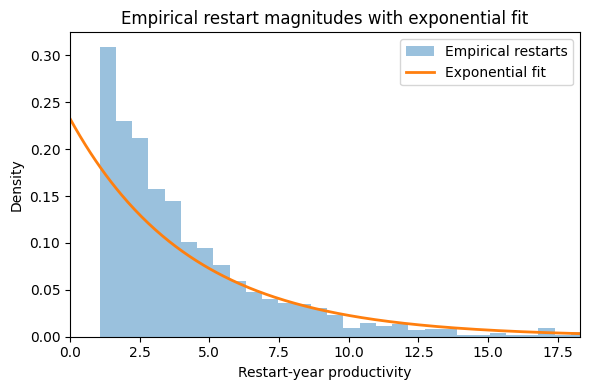

In [29]:
# Cell 11: restart dx check

x_max = np.quantile(restart_q_empirical, 0.99)
x_grid = np.linspace(0, x_max, 300)
restart_pdf = lambda_restart * np.exp(-lambda_restart * x_grid)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    restart_q_empirical,
    bins=50,
    density=True,
    alpha=0.45,
    label="Empirical restarts")

ax.plot(
    x_grid,
    restart_pdf,
    linewidth=2,
    label="Exponential fit")

ax.set_xlim(0, x_max)
ax.set_xlabel("Restart-year productivity")
ax.set_ylabel("Density")
ax.set_title("Empirical restart magnitudes with exponential fit")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "hurdle_ar1_grw_s_restartFit.png", dpi=300, bbox_inches="tight")
plt.show()


In [30]:
# Cell 12: simulation helpers

def make_ar1_stage_lookup(stage_ar1_params):
    return (stage_ar1_params
        .set_index("stage")[["intercept", "beta", "sigma_resid"]].to_dict("index"))

ar1_stage_lookup = make_ar1_stage_lookup(stage_ar1_params)


def draw_next_binary_state(b_current, P, rng):
    p_to_some = np.where(
        b_current == 0,
        P.loc[0, 1],
        P.loc[1, 1])

    return rng.binomial(1, p_to_some, size=len(b_current)).astype(int)


def simulate_binary_markov_paths(year_P, n=N, Y=Y, p_init_active=p_init_active, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    b_paths = np.zeros((Y + 1, n), dtype=int)
    b_paths[0] = rng.binomial(1, p_init_active, size=n).astype(int)

    for t in range(Y):
        b_paths[t + 1] = draw_next_binary_state(b_paths[t], year_P[t], rng)

    return b_paths


def simulate_productivity_given_binary_path(
    b_paths,
    ar1_stage_lookup,
    alpha_q0_pos=alpha_q0_pos,
    alpha_restart=alpha_restart,
    Y=Y,
    rng=None):

    if rng is None:
        rng = np.random.default_rng()

    n = b_paths.shape[1]
    trajectories = np.zeros_like(b_paths, dtype=float)
    z_paths = np.full_like(trajectories, np.nan, dtype=float)

    init_active = b_paths[0] == 1
    q0 = np.zeros(n)
    q0[init_active] = rng.exponential(scale=alpha_q0_pos, size=init_active.sum())
    trajectories[0] = q0
    z_paths[0, init_active] = np.log(q0[init_active])

    for t in range(Y):
        b_now = b_paths[t]
        b_next = b_paths[t + 1]

        q_next = np.zeros(n)
        z_next = np.full(n, np.nan)

        restart = (b_now == 0) & (b_next == 1)
        continued = (b_now == 1) & (b_next == 1)

        if restart.sum() > 0:
            q_restart = rng.exponential(scale=alpha_restart, size=restart.sum())
            q_next[restart] = q_restart
            z_next[restart] = np.log(q_restart)

        if continued.sum() > 0:
            stage = assign_career_stage(t)

            intercept = ar1_stage_lookup[stage]["intercept"]
            beta = ar1_stage_lookup[stage]["beta"]
            sigma = ar1_stage_lookup[stage]["sigma_resid"]

            shock = rng.normal(loc=0, scale=sigma, size=continued.sum())
            z_cont = intercept + beta * z_paths[t, continued] + shock

            q_next[continued] = np.exp(z_cont)
            z_next[continued] = z_cont

        trajectories[t + 1] = q_next
        z_paths[t + 1] = z_next

    return trajectories, z_paths


def simulate_combined_model(year_P, ar1_stage_lookup, n=N, Y=Y, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    b_paths = simulate_binary_markov_paths(
        year_P=year_P,
        n=n,
        Y=Y,
        p_init_active=p_init_active,
        rng=rng)

    trajectories, z_paths = simulate_productivity_given_binary_path(
        b_paths=b_paths,
        ar1_stage_lookup=ar1_stage_lookup,
        alpha_q0_pos=alpha_q0_pos,
        alpha_restart=alpha_restart,
        Y=Y,
        rng=rng)

    return trajectories, z_paths, b_paths


def trajectories_to_dataframe_combined(trajs, b_paths):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({
        "CareerAge": np.repeat(years, len(ix)),
        "ix": np.tile(ix, len(years)),
        "pubs_adj": trajs.reshape(-1),
        "state": b_paths.reshape(-1),})

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["state_next"] = df_sim.groupby("ix")["state"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]

    df_sim["log_pubs_adj"] = np.where(df_sim["pubs_adj"] > 0, np.log(df_sim["pubs_adj"]), np.nan)
    df_sim["log_pubs_next"] = np.where(df_sim["pubs_adj_next"] > 0, np.log(df_sim["pubs_adj_next"]), np.nan)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna(subset=["pubs_adj_next", "state_next"]).copy()


In [31]:
# Cell 13: simulate combined hurdle AR(1)

trajs_combined, z_trajs_combined, b_trajs_combined = simulate_combined_model(
    year_P=year_P,
    ar1_stage_lookup=ar1_stage_lookup,
    n=N,
    Y=Y,
    rng=rng)

trajs = trajs_combined
b_trajs = b_trajs_combined

df_trajs = trajectories_to_dataframe_combined(trajs, b_trajs)

print("trajectory array shape:", trajs.shape)
print("binary path array shape:", b_trajs.shape)
print()
print("sim'd state fractions:")
for t in [0, 5, 10, 15, 20]:
    print(f"Year {t}: zero={(b_trajs[t] == 0).mean():.4f}, active={(b_trajs[t] == 1).mean():.4f}")

print()
print("sim'd positive log increments:")
print(df_trajs.loc[(df_trajs["state"] == 1) & (df_trajs["state_next"] == 1), "log_delta"].describe())


trajectory array shape: (21, 50000)
binary path array shape: (21, 50000)

sim'd state fractions:
Year 0: zero=0.2086, active=0.7914
Year 5: zero=0.1132, active=0.8868
Year 10: zero=0.1458, active=0.8542
Year 15: zero=0.1622, active=0.8378
Year 20: zero=0.1744, active=0.8256

sim'd positive log increments:
count    763493.000000
mean          0.083602
std           0.752433
min          -3.299355
25%          -0.423118
50%           0.071498
75%           0.576289
max           5.535961
Name: log_delta, dtype: float64


/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [32]:
stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]

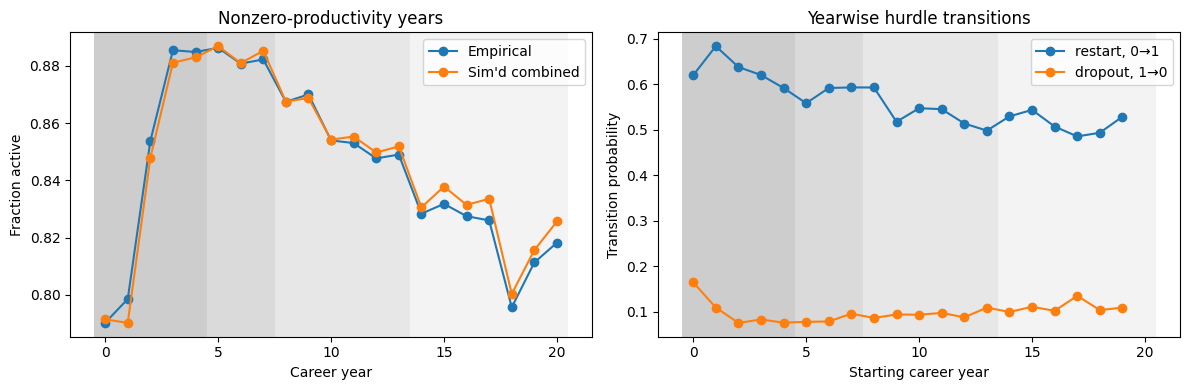

In [33]:
# Cell 14: binary path dx

emp_state_by_year = (
    df[df[age_col].between(0, Y)]
    .groupby(age_col)["state"]
    .agg(n="size", frac_active="mean")
    .reset_index()
    .rename(columns={age_col: "year"}))

sim_state_by_year = pd.DataFrame({
    "year": np.arange(Y + 1),
    "frac_active": b_trajs_combined.mean(axis=1),
    "frac_zero": 1 - b_trajs_combined.mean(axis=1),})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )

axes[0].plot(emp_state_by_year["year"], emp_state_by_year["frac_active"], marker="o", label="Empirical", zorder = 3)
axes[0].plot(sim_state_by_year["year"], sim_state_by_year["frac_active"], marker="o", label="Sim'd combined", zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Fraction active")
axes[0].set_title("Nonzero-productivity years")
axes[0].legend()

axes[1].plot(year_transition_summary["year"], year_transition_summary["P_nothing_to_something"], marker="o", label="restart, 0→1", zorder = 3)
axes[1].plot(year_transition_summary["year"], year_transition_summary["P_something_to_nothing"], marker="o", label="dropout, 1→0", zorder = 3)
axes[1].set_xlabel("Starting career year")
axes[1].set_ylabel("Transition probability")
axes[1].set_title("Yearwise hurdle transitions")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "hurdle_ar1_grw_s_Dx.png", dpi=300, bbox_inches="tight")
plt.show()


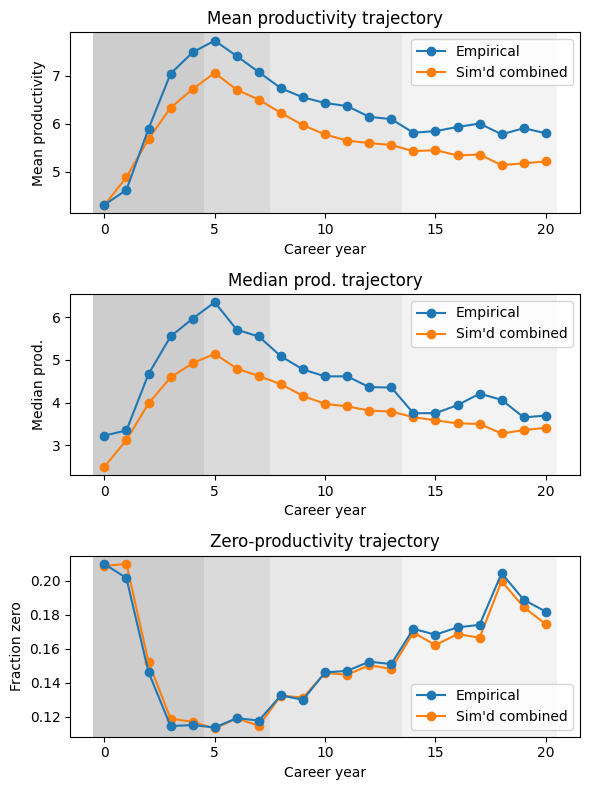

In [34]:
# Cell 15: canonical trajectory check

emp_mean = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .mean())

emp_median = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .median())

emp_frac_zero = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .apply(lambda x: (x == 0).mean()))

sim_mean = trajs_combined.mean(axis=1)
sim_median = np.median(trajs_combined, axis=1)
sim_frac_zero = (trajs_combined == 0).mean(axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label="Sim'd combined")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label="Sim'd combined")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

axes[2].plot(emp_frac_zero.index, emp_frac_zero.values, marker="o", label="Empirical", zorder = 3)
axes[2].plot(years, sim_frac_zero, marker="o", label="Sim'd combined")
axes[2].set_xlabel("Career year")
axes[2].set_ylabel("Fraction zero")
axes[2].set_title("Zero-productivity trajectory")
axes[2].legend()

plt.tight_layout()

plt.savefig(FIGURES / "hurdle_ar1_grw_s_trajectories.png", dpi=300, bbox_inches="tight")

plt.show()


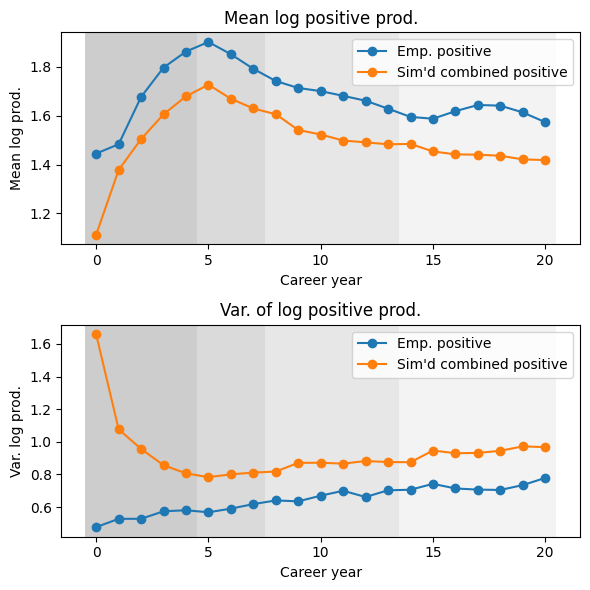

In [35]:
# Cell 16A: yearwise log distrib dx

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_combined[t])

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
axes[0].plot(
    emp_year_stats["year"],
    emp_year_stats["mean_log_prod_pos"],
    marker="o",
    label="Emp. positive", zorder = 3
)
axes[0].plot(
    sim_year_stats["year"],
    sim_year_stats["mean_log_prod_pos"],
    marker="o",
    label="Sim'd combined positive", zorder = 3
)
axes[0].set_title("Mean log positive prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(
    emp_year_stats["year"],
    emp_year_stats["var_log_prod_pos"],
    marker="o",
    label="Emp. positive", zorder = 3
)
axes[1].plot(
    sim_year_stats["year"],
    sim_year_stats["var_log_prod_pos"],
    marker="o",
    label="Sim'd combined positive", zorder = 3
)
axes[1].set_title("Var. of log positive prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / "hurdle_ar1_grw_s_posLog.png", dpi=300, bbox_inches="tight")
plt.show()

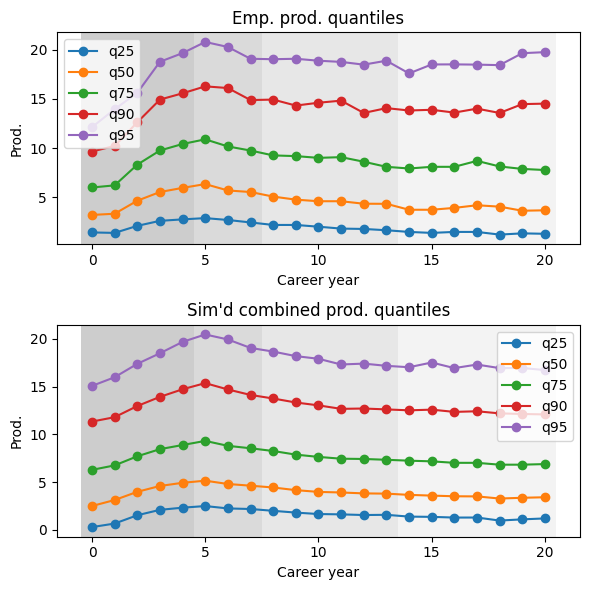

In [36]:
# Cell 16B: yearwise quantile distrib dx

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
for qcol in qcols:
    axes[0].plot(
        emp_year_stats["year"],
        emp_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[0].set_title("Emp. prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()

for qcol in qcols:
    axes[1].plot(
        sim_year_stats["year"],
        sim_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[1].set_title("Sim'd combined prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / "hurdle_ar1_grw_s_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()

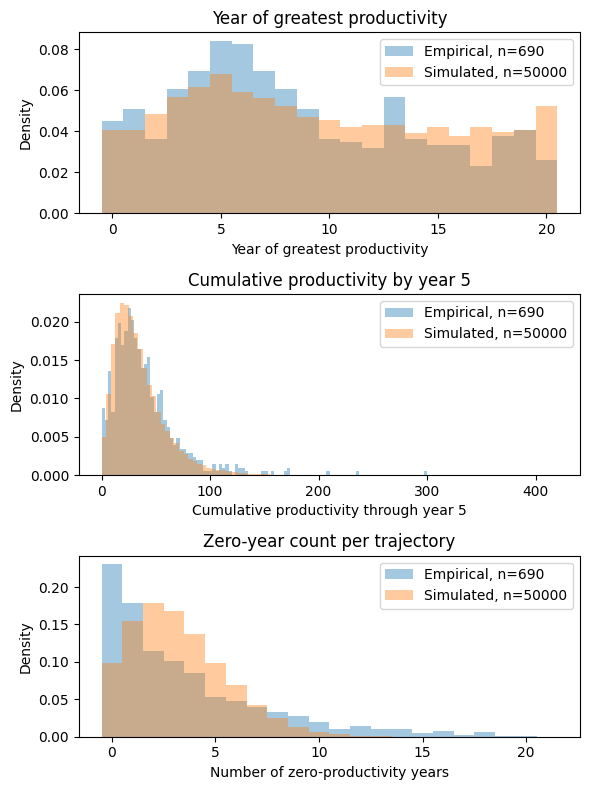

Full empirical trajectories: 690
Simulated trajectories: 50000
KS year of greatest productivity: KstestResult(statistic=np.float64(0.07862492753623185), pvalue=np.float64(0.0004147101393794321), statistic_location=np.int64(9), statistic_sign=np.int8(1))
KS cumulative productivity by year 5: KstestResult(statistic=np.float64(0.06778231884057973), pvalue=np.float64(0.00364613476968292), statistic_location=np.float64(40.901258627105705), statistic_sign=np.int8(-1))
KS zero-year count: KstestResult(statistic=np.float64(0.15497565217391307), pvalue=np.float64(9.487995177832278e-15), statistic_location=np.int64(1), statistic_sign=np.int8(1))


In [37]:
# Cell 17: dx, norm'd

emp_panel = (working_df[working_df["CareerAge"].between(0, Y)].pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj"))

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)
emp_zero_count = (emp_panel_full == 0).sum(axis=1)

sim_year_max = np.argmax(trajs_combined, axis=0)
sim_cum_y5 = trajs_combined[0:6, :].sum(axis=0)
sim_zero_count = (trajs_combined == 0).sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)
ks_zero_count = stats.ks_2samp(emp_zero_count, sim_zero_count)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))

axes[0].hist(
    emp_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_year_max)}")

axes[0].hist(
    sim_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_year_max)}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(
    emp_cum_y5,
    bins=100,
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_cum_y5)}")

axes[1].hist(
    sim_cum_y5,
    bins=100,
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_cum_y5)}")

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

axes[2].hist(
    emp_zero_count,
    bins=np.arange(-0.5, Y + 2.5, 1),
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_zero_count)}")

axes[2].hist(
    sim_zero_count,
    bins=np.arange(-0.5, Y + 2.5, 1),
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_zero_count)}")

axes[2].set_xlabel("Number of zero-productivity years")
axes[2].set_ylabel("Density")
axes[2].set_title("Zero-year count per trajectory")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES / "hurdle_ar1_grw_s_distribs.png", dpi=300, bbox_inches="tight")
plt.show()

print("Full empirical trajectories:", len(emp_panel_full))
print("Simulated trajectories:", trajs_combined.shape[1])
print("KS year of greatest productivity:", ks_year_max)
print("KS cumulative productivity by year 5:", ks_cum_y5)
print("KS zero-year count:", ks_zero_count)


In [38]:
# Cell 18: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "empirical_frac_zero_y0": emp_frac_zero.loc[0],
    "empirical_frac_zero_y5": emp_frac_zero.loc[5],
    "empirical_frac_zero_y10": emp_frac_zero.loc[10],
    "empirical_frac_zero_y20": emp_frac_zero.loc[20],
    "simulated_frac_zero_y0": sim_frac_zero[0],
    "simulated_frac_zero_y5": sim_frac_zero[5],
    "simulated_frac_zero_y10": sim_frac_zero[10],
    "simulated_frac_zero_y20": sim_frac_zero[20],
    "lambda_restart": lambda_restart,
    "alpha_restart": alpha_restart,
    "restart_n": len(restart_q_empirical),
    "simulated_y20_q95": np.quantile(trajs_combined[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_combined[20], 0.99),
    "simulated_y20_max": np.max(trajs_combined[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue,
    "ks_zero_count_stat": ks_zero_count.statistic,
    "ks_zero_count_p": ks_zero_count.pvalue,}

summary_df = pd.DataFrame([summary])

print("Yearwise transition summary")
display(year_transition_summary.round(3))

print("Stagewise positive-only AR(1) params")
display(stage_ar1_params)

print("Restart exponential params")
display(pd.DataFrame([{
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "alpha_q0_pos": alpha_q0_pos,
    "lambda_q0_pos": lambda_q0_pos,
    "p_init_active": p_init_active,}]))

print("Summary")
display(summary_df)


Yearwise transition summary


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


Stagewise positive-only AR(1) params


,stage,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0-4,8298,0.872684,0.549230,0.635833,0.404284,1.935984,0.578916,1.488860e-15,0.635833
1,5-7,5159,0.706953,0.591138,0.638334,0.407471,1.729075,0.626343,-7.051713e-16,0.638334
2,8-13,8084,0.617526,0.621251,0.651541,0.424506,1.630435,0.691324,7.669933e-16,0.651541
3,14-20,4958,0.558044,0.654173,0.648712,0.420827,1.613650,0.735637,7.588390e-16,0.648712


Restart exponential params


,alpha_restart,lambda_restart,restart_n,alpha_q0_pos,lambda_q0_pos,p_init_active
0,4.299784,0.23257,3061,5.447328,0.183576,0.790237


Summary


,empirical_mean_y0,empirical_mean_y5,empirical_mean_y10,empirical_mean_y20,simulated_mean_y0,simulated_mean_y5,simulated_mean_y10,simulated_mean_y20,empirical_median_y0,empirical_median_y5,...,restart_n,simulated_y20_q95,simulated_y20_q99,simulated_y20_max,ks_year_max_stat,ks_year_max_p,ks_cum_y5_stat,ks_cum_y5_p,ks_zero_count_stat,ks_zero_count_p
0,4.304679,7.729319,6.428626,5.797863,4.300163,7.055792,5.772617,5.211964,3.225469,6.352937,...,3061,16.726771,30.661284,137.330432,0.078625,0.000415,0.067782,0.003646,0.154976,9.487995e-15


In [39]:
# Cell 19: save outputs

year_transition_summary.to_csv(RESULTS / "hurdle_ar1_grw_s_.csv", index=False)
stage_transition_summary.to_csv(RESULTS / "transSummary.csv", index=False)
stage_ar1_params.to_csv(RESULTS / "hurdle_ar1_grw_s_posStageLog.csv", index=False)
global_ar1_params.to_csv(RESULTS / "hurdle_ar1_grw_s_pos_globalLog.csv", index=False)
emp_year_stats.to_csv(RESULTS / "hurdle_ar1_grw_s_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / "hurdle_ar1_grw_s_simYearStats.csv", index=False)
summary_df.to_csv(RESULTS / "hurdle_ar1_grw_s_Summary.csv", index=False)

def matrix_dict_to_frame(matrix_dict, level_name):
    rows = []
    for key, mat in matrix_dict.items():
        rows.append({
            level_name: key,
            "P_nothing_to_nothing": mat.loc[0, 0],
            "P_nothing_to_something": mat.loc[0, 1],
            "P_something_to_nothing": mat.loc[1, 0],
            "P_something_to_something": mat.loc[1, 1],})
    return pd.DataFrame(rows)

matrix_dict_to_frame(year_P, "year").to_csv(RESULTS / "hurdle_ar1_grw_s_yearPMatrices.csv", index=False)
matrix_dict_to_frame(stage_P, "stage").to_csv(RESULTS / "hurdle_ar1_grw_s_stagePMatrices.csv", index=False)

with open(RESULTS / "hurdle_ar1_grw_s_report.txt", "w") as f:
    f.write("combined Markov-hurdled stagewise AR(1) report\n")
    f.write("\n\n")

    f.write("Model\n")
    f.write("\n")
    f.write("B_{t+1} | B_t ~ Bernoulli(P_t[B_t, 1])\n")
    f.write("Q_{t+1} = 0 if B_{t+1}=0\n")
    f.write("Q_{t+1} ~ Exponential(lambda_R) if B_t=0 and B_{t+1}=1\n")
    f.write("log(Q_{t+1}) = intercept_s + beta_s log(Q_t) + error_{t,s} if B_t=1 and B_{t+1}=1\n")
    f.write("error_{t,s} ~ Normal(0, sigma_s^2)\n\n")

    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n")
    f.write(f"p_init_active = {p_init_active}\n")
    f.write(f"alpha_q0_pos = {alpha_q0_pos}\n")
    f.write(f"lambda_q0_pos = {lambda_q0_pos}\n")
    f.write(f"alpha_restart = {alpha_restart}\n")
    f.write(f"lambda_restart = {lambda_restart}\n\n")

    f.write("Yearwise binary transition summary\n")
    f.write("\n")
    f.write(year_transition_summary.to_string(index=False))

    f.write("\n\nStagewise positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(stage_ar1_params.to_string(index=False))

    f.write("\n\nGlobal positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(global_ar1_params.to_string(index=False))

    f.write("\n\nsummary\n")
    f.write("-------\n")
    f.write(summary_df.to_string(index=False))


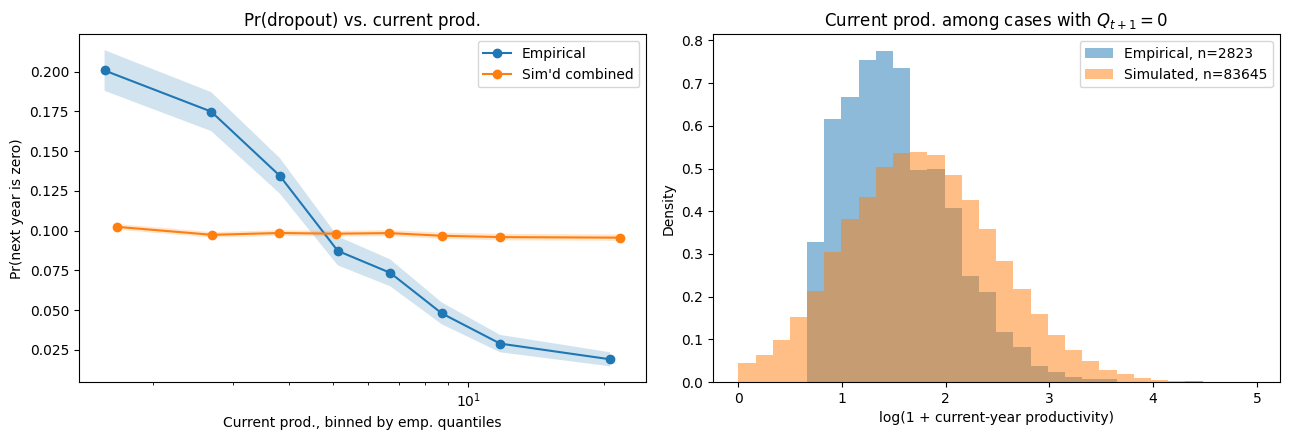

Empirical dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",3760,0.200798,1.558408,1.502068,Empirical,1.558408,0.006533,0.187993,0.213603
1,"(2.181, 3.229]",3687,0.174939,2.687266,2.644809,Empirical,2.687266,0.006257,0.162676,0.187202
2,"(3.229, 4.419]",3575,0.134545,3.815607,3.811037,Empirical,3.815607,0.005707,0.123359,0.145731
3,"(4.419, 5.829]",3700,0.087297,5.131218,5.084822,Empirical,5.131218,0.004640,0.078202,0.096393
4,"(5.829, 7.622]",3631,0.073533,6.704440,6.691238,Empirical,6.704440,0.004332,0.065044,0.082023
5,"(7.622, 10.037]",3711,0.047966,8.732543,8.706188,Empirical,8.732543,0.003508,0.041090,0.054841
6,"(10.037, 14.001]",3592,0.028953,11.763405,11.657458,Empirical,11.763405,0.002798,0.023470,0.034437
7,"(14.001, 80.687]",3666,0.019094,20.622869,18.392702,Empirical,20.622869,0.002260,0.014664,0.023525


Simulated dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",108910,0.102424,1.659605,1.670254,Simulated,1.659605,0.000919,0.100623,0.104225
1,"(2.181, 3.229]",111920,0.097400,2.700733,2.699502,Simulated,2.700733,0.000886,0.095663,0.099137
2,"(3.229, 4.419]",112302,0.098547,3.805542,3.794825,Simulated,3.805542,0.000889,0.096804,0.100290
3,"(4.419, 5.829]",106540,0.098123,5.090937,5.075960,Simulated,5.090937,0.000911,0.096336,0.099909
4,"(5.829, 7.622]",98250,0.098483,6.672481,6.645000,Simulated,6.672481,0.000951,0.096620,0.100347
5,"(7.622, 10.037]",87151,0.096820,8.734746,8.691176,Simulated,8.734746,0.001002,0.094857,0.098784
6,"(10.037, 14.001]",78042,0.095974,11.776843,11.661789,Simulated,11.776843,0.001054,0.093907,0.098041
7,"(14.001, 80.687]",86729,0.095608,21.756133,18.857832,Simulated,21.756133,0.000998,0.093651,0.097565


In [40]:
# conditioned dropout 

emp_dx = working_df_fit.loc[
    working_df_fit["pubs_adj"].notna() &
    working_df_fit["pubs_adj_next"].notna(),
    ["CareerAge", "pubs_adj", "pubs_adj_next"]
].copy()

emp_dx = emp_dx.loc[emp_dx["pubs_adj"] > 0].copy()
emp_dx["drops_to_zero"] = (emp_dx["pubs_adj_next"] == 0).astype(int)


sim_dx = pd.DataFrame({
    "CareerAge": np.repeat(np.arange(Y), trajs_combined.shape[1]),
    "pubs_adj": trajs_combined[:-1, :].ravel(),
    "pubs_adj_next": trajs_combined[1:, :].ravel()})

sim_dx = sim_dx.loc[sim_dx["pubs_adj"] > 0].copy()
sim_dx["drops_to_zero"] = (sim_dx["pubs_adj_next"] == 0).astype(int)

n_bins = 8

bin_edges = np.quantile(emp_dx["pubs_adj"], np.linspace(0, 1, n_bins + 1))

bin_edges = np.unique(bin_edges)

if len(bin_edges) < 3:
    raise ValueError("Not enough unique emp bin edges")

emp_dx["prod_bin"] = pd.cut(
    emp_dx["pubs_adj"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)

sim_dx["prod_bin"] = pd.cut(
    sim_dx["pubs_adj"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)

def summarize_dropout_by_bin(df, label):
    out = (
        df.groupby("prod_bin", observed=False)
        .agg(
            n=("drops_to_zero", "size"),
            dropout_rate=("drops_to_zero", "mean"),
            mean_q_t=("pubs_adj", "mean"),
            median_q_t=("pubs_adj", "median")
        )
        .reset_index()
    )

    out["source"] = label
    out["bin_mid"] = out["mean_q_t"]

    out["se"] = np.sqrt(out["dropout_rate"] * (1 - out["dropout_rate"]) / out["n"])
    out["lower"] = np.clip(out["dropout_rate"] - 1.96 * out["se"], 0, 1)
    out["upper"] = np.clip(out["dropout_rate"] + 1.96 * out["se"], 0, 1)

    return out

emp_bin_summary = summarize_dropout_by_bin(emp_dx, "Empirical")
sim_bin_summary = summarize_dropout_by_bin(sim_dx, "Simulated")

dropout_bin_summary = pd.concat([emp_bin_summary, sim_bin_summary], ignore_index=True)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    emp_bin_summary["bin_mid"],
    emp_bin_summary["dropout_rate"],
    marker="o",
    label="Empirical"
)

axes[0].fill_between(
    emp_bin_summary["bin_mid"],
    emp_bin_summary["lower"],
    emp_bin_summary["upper"],
    alpha=0.20
)

axes[0].plot(
    sim_bin_summary["bin_mid"],
    sim_bin_summary["dropout_rate"],
    marker="o",
    label="Sim'd combined"
)

axes[0].fill_between(
    sim_bin_summary["bin_mid"],
    sim_bin_summary["lower"],
    sim_bin_summary["upper"],
    alpha=0.20
)

axes[0].set_xlabel("Current prod., binned by emp. quantiles")
axes[0].set_ylabel("Pr(next year is zero)")
axes[0].set_title("Pr(dropout) vs. current prod.")
axes[0].legend()

axes[0].set_xscale("log")

emp_prezero = emp_dx.loc[emp_dx["drops_to_zero"] == 1, "pubs_adj"]
sim_prezero = sim_dx.loc[sim_dx["drops_to_zero"] == 1, "pubs_adj"]

hist_bins = np.histogram_bin_edges(
    np.log1p(pd.concat([emp_prezero, sim_prezero])),
    bins=30
)

axes[1].hist(
    np.log1p(emp_prezero),
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label=f"Empirical, n={len(emp_prezero)}"
)

axes[1].hist(
    np.log1p(sim_prezero),
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label=f"Simulated, n={len(sim_prezero)}"
)

axes[1].set_xlabel("log(1 + current-year productivity)")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Current prod. among cases with $Q_{t+1}=0$")
axes[1].legend()

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES / "hurdle_ar1_grw_s_condProdDropout.png",
    dpi=300,
    bbox_inches="tight"
)

dropout_bin_summary.to_csv(
    RESULTS / "hurdle_ar1_grw_s_Summary.csv",
    index=False
)

print("Empirical dropout by current productivity bin:")
display(emp_bin_summary)

print("Simulated dropout by current productivity bin:")
display(sim_bin_summary)